# Continuous Optimisation

## Imports

In [59]:
# class generation
import numpy as np
from numpy import linalg as LA
from typing import Tuple, Callable, Optional
# plots & visualization
import matplotlib
import matplotlib.pyplot as plt

## Structural Mechanics

In [83]:
class StructuralMechanics:
    """
    Define the objective function for the gradient descent of the structural mechanics problem.
    """
    
    def __init__(self, n: int = 20):
        # check whether u is in R^n
        assert n > 0, f"n = {n} is not a positive integer."

        self.n: int = n
        self.K: np.ndarray = np.zeros((self.n, self.n))
        self.b: np.ndarray = np.zeros(self.n)

        # b = (0 0 ... 0 1)
        self.b[-1] = 1

        # K = (  2 -1  0 ... 0 )
        #     ( -1  2 -1 ... 0 )
        #     (  0 -1  .     0 )
        #     (  .      .    . )
        #     (  .        . -1 )
        #     (  0  ... 0 -1 2 )
        for i in range(self.n):
            self.K[i, i] = 2
            if i > 0:
                self.K[i - 1, i] = -1
            if i < self.n - 1:
                self.K[i + 1, i] = -1
            if i == self.n - 1:
                self.K[i, i] = 1

        eigenvalues = LA.eigvalsh(self.K)
        self.mu: float = float(min(eigenvalues))
        self.eta: float = float(max(eigenvalues))
        self.max_alpha: float = float(2 / self.eta) # upper bound for alpha which guarantees gradient descent (prop 3.3)
        
    def _objective(self, u: np.ndarray) -> float:
        """Compute the objective of the function."""
        # E(u) = 1/2 * u^T * K * u - b^T * u
        return 0.5 * u.T @ self.K @ u - self.b.T @ u
    
    def _gradient(self, u: np.ndarray) -> np.ndarray:
        """Compute the gradient of the function."""
        # grad E(u) = K * u - b
        return self.K @ u - self.b

    def _hessian(self) -> np.ndarray:
        """Compute the Hessian of the function."""   
        # hessian E(u) = K     
        return self.K.copy()

    def gradient_descent(
            self, 
            u_0: np.ndarray, 
            alpha: float = None, 
            epsilon: float = 1e-8, 
            max_iter: int = 10000,
            track_history: bool = False  # for plotting purposes
            ) -> Tuple[np.ndarray, int, float]:
        """Gradient Descent with Fixed Step Size
        
        Args:
            u_0 (np.ndarray): initial point
            alpha (float): step size
            epsilon (float, optional): error margin. Defaults to 1e-8.
            max_iter (int, optional): maximum iterations (for debugging). Defaults to 10000.

        Raises:
            ValueError: Objective function value became infinite.
            RuntimeError: Way too many iterations for the algorithm.

        Returns:
            Tuple[np.ndarray, int, float]: Returns current position, current step number, and current objective value.
        """ 
        assert 0 < epsilon, f"epsilon = {epsilon} is not > 0."
        
        if alpha is None: alpha = float(self.max_alpha / 2)
        assert 0 < alpha, f"alpha = {alpha} is not > 0."
        assert alpha < self.max_alpha, f"alpha = {alpha} does not guarantee gradient descent, try alpha < {self.max_alpha}."
        
        u_k = u_0.copy()

        # history tracking
        if track_history:
            hist_obj = []
            hist_grad_norm = []

        for k in range(max_iter):

            grad_k = self._gradient(u_k)
            grad_norm = LA.norm(grad_k)

            if track_history:
                hist_obj.append(self._objective(u_k))
                hist_grad_norm.append(float(grad_norm))
            
            if grad_norm < epsilon:
                if track_history:
                    return u_k, k, self._objective(u_k), {'obj': hist_obj, 'grad': hist_grad_norm}
                return u_k, k, self._objective(u_k)

            u_k -= alpha * grad_k
            
            if not np.isfinite(self._objective(u_k)):
                raise ValueError("Objective became non-finite")
    
        raise RuntimeError(f"Did not converge within {max_iter} iterations")

    def optimal_step(self, 
        u_k: np.ndarray, 
        d_k: np.ndarray
        ) -> float:
        """Optimal choice of alpha for quadratic functions in given by alpha = -(grad E(u) * d) / (d^T * K * d).

        Args:
            u_k (np.ndarray): current point
            d_k (np.ndarray): descent direction

        Returns:
            float: desired alpha
        """
        grad = self._gradient(u_k)
        numerator = - grad @ d_k
        denominator = d_k.T @ self.K @ d_k
        if abs(denominator) < 1e-12:
            return 0.0
        return min(float(numerator / denominator), self.max_alpha)

    def GD_exact_line_search(self,
        u_0: np.ndarray,
        epsilon: float = 1e-8,
        max_iter: int = 10000,
        track_history: bool = False  # for plotting purposes
        ) -> Tuple[np.ndarray, int, float]:
        """Gradient Descent with Exact Line Search

        Args:
            u_0 (np.ndarray): initial point
            epsilon (float, optional): error margin. Defaults to 1e-8.
            max_iter (int, optional): maximum iterations (for debugging). Defaults to 10000.

        Raises:
            ValueError: Objective function value became infinite.
            RuntimeError: Way too many iterations for the algorithm.

        Returns:
            Tuple[np.ndarray, int, float]: Returns current position, current step number, and current objective value.
        """        
        assert 0 < epsilon, f"epsilon = {epsilon} is not > 0."
        u_k = u_0.copy()

        # history tracking
        if track_history:
            hist_obj = []
            hist_grad_norm = []
            hist_alpha = []

        prev_obj = float('inf')
        stagnation_count = 0  # ADD TRACKING
        STAGNATION_THRESHOLD = 50  # NEW CONSTANT

        for k in range(max_iter):
            grad_k = self._gradient(u_k)
            grad_norm = LA.norm(grad_k)
            alpha_k = self.optimal_step(u_k, -grad_k)

            if track_history:
                hist_obj.append(self._objective(u_k))
                hist_grad_norm.append(float(grad_norm))
                hist_alpha.append(alpha_k)
            
            if grad_norm < epsilon:
                if track_history:
                    return u_k, k, self._objective(u_k), {'obj': hist_obj, 'grad': hist_grad_norm, 'alpha': hist_alpha}
                return u_k, k, self._objective(u_k)

            u_k -= alpha_k * grad_k

            # STAGNATION CHECK
            curr_obj = self._objective(u_k)
            if abs(curr_obj - prev_obj) < 1e-12:
                stagnation_count += 1
                if stagnation_count > STAGNATION_THRESHOLD:
                    print(f"  Warning: Stagnated after {k} iterations, ||grad|| = {grad_norm:.2e}")
                    if track_history:
                        return u_k, k, curr_obj, {'obj': hist_obj, 'grad': hist_grad_norm, 'alpha': hist_alpha}
                    return u_k, k, curr_obj  # Accept current solution
            else:
                stagnation_count = 0
            prev_obj = curr_obj
            
            if not np.isfinite(self._objective(u_k)):
                raise ValueError("Objective became non-finite")
    
        raise RuntimeError(f"Did not converge within {max_iter} iterations")

    def armijo_condition(self,
        u: np.ndarray,
        d: np.ndarray,
        alpha: float,
        c: float
        ) -> bool:
        """Check E(u + alpha * d) <= E(u) + c* alpha * grad E(u)^T * d.

        Args:
            d (np.ndarray): descent direction
            c (float): constant coefficient
            alpha (float): step size

        Returns:
            bool: Is the Armijo condition satisfied.
        """        
        assert (0 < c and c < 1), f"c = {c} is not in (0, 1)."
        assert 0 < alpha, f"alpha = {alpha} is not > 0."
        assert alpha < self.max_alpha, f"alpha = {alpha} does not guarantee gradient descent, try alpha < {self.max_alpha}."
        step = self._objective(u + alpha * d)
        current = self._objective(u)
        change = c * alpha * self._gradient(u).T @ d
        return (step <= current + change)

    def backtracking(self,
        u_k: np.ndarray,
        d_k: np.ndarray,
        alpha_0: float = None,
        rho: float = 0.5, 
        c: float = 1e-4,
        max_iter: int = 10000
        ) -> float:
        """backtracking line search for sufficiently optimal alpha

        Args:
            u_k (np.ndarray): current point
            d_k (np.ndarray): descent direcion
            alpha_0 (float, optional): initial alpha. Defaults to 1.0.
            rho (float, optional): constant rho. Defaults to 0.5.
            c (float, optional): constant c. Defaults to 1e-4.
            max_iter (int, optional): maximum iterations (for debugging). Defaults to 10000.

        Returns:
            float: new sufficient alpha
        """        
        assert (0 < c and c < 1), f"c = {c} is not in (0, 1)."
        assert (0 < rho and rho < 1), f"rho = {rho} is not in (0, 1)."
        
        if alpha_0 is None: alpha_0 = float(self.max_alpha / 2)
        assert 0 < alpha_0, f"alpha = {alpha_0} is not > 0."
        assert alpha_0 < self.max_alpha, f"alpha = {alpha_0} does not guarantee gradient descent, try alpha < {self.max_alpha}."
        
        alpha_new = alpha_0
        
        for _ in range(max_iter):
            
            if self.armijo_condition(u_k, d_k, alpha_new, c):
                return float(alpha_new)
            
            alpha_new *= rho

        return float(alpha_new)

    def GD_inexact_line_search(self,
        u_0: np.ndarray,
        alpha_0: float = None,
        rho: float = 0.5,
        c: float = 1e-4,
        epsilon: float = 1e-8,
        max_iter: int = 10000,
        track_history: bool = False  # for plotting purposes
        ) -> Tuple[np.ndarray, int, float]:
        """Gradient Descent with Inexact Line Search

        Args:
            u_0 (np.ndarray): initial point
            alpha_0 (float, optional): initial alpha. Defaults to 1.0.
            rho (float, optional): constant rho. Defaults to 0.5.
            c (float, optional): constant c. Defaults to 1e-4.
            epsilon (float, optional): error margin. Defaults to 1e-8.
            max_iter (int, optional): maximum iterations (for debugging). Defaults to 10000.

        Raises:
            ValueError: Objective function value became infinite.
            RuntimeError: Way too many iterations for the algorithm.

        Returns:
            Tuple[np.ndarray, int, float]: Returns current position, current step number, and current objective value.
        """     
        assert 0 < epsilon, f"epsilon = {epsilon} is not > 0."
        assert (0 < c and c < 1), f"c = {c} is not in (0, 1)."
        assert (0 < rho and rho < 1), f"rho = {rho} is not in (0, 1)."
        
        if alpha_0 is None: alpha_0 = float(self.max_alpha / 2)
        assert 0 < alpha_0, f"alpha = {alpha_0} is not > 0."
        assert alpha_0 < self.max_alpha, f"alpha = {alpha_0} does not guarantee gradient descent, try alpha < {self.max_alpha}."
        
        u_k = u_0.copy()
        alpha_k = alpha_0

        # history tracking
        if track_history:
            hist_obj = []
            hist_grad_norm = []
            hist_alpha = []

        prev_obj = float('inf')
        stagnation_count = 0  # ← ADD TRACKING
        STAGNATION_THRESHOLD = 50  # NEW CONSTANT

        for k in range(max_iter):
            grad_k = self._gradient(u_k) # = d_k
            grad_norm = LA.norm(grad_k)
            alpha_k = self.backtracking(u_k=u_k, d_k=(-grad_k), alpha_0=alpha_k, rho=rho, c=c)

            if track_history:
                hist_obj.append(self._objective(u_k))
                hist_grad_norm.append(float(grad_norm))
                hist_alpha.append(alpha_k)
            
            if grad_norm < epsilon:
                if track_history:
                    return u_k, k, self._objective(u_k), {'obj': hist_obj, 'grad': hist_grad_norm, 'alpha': hist_alpha}
                return u_k, k, self._objective(u_k)

            u_k -= alpha_k * grad_k

            # STAGNATION CHECK
            curr_obj = self._objective(u_k)
            if abs(curr_obj - prev_obj) < 1e-12:
                stagnation_count += 1
                if stagnation_count > STAGNATION_THRESHOLD:
                    print(f"  Warning: Stagnated after {k} iterations, ||grad|| = {grad_norm:.2e}")
                    if track_history:
                        return u_k, k, curr_obj, {'obj': hist_obj, 'grad': hist_grad_norm, 'alpha': hist_alpha}
                    return u_k, k, curr_obj  # Accept current solution
            else:
                stagnation_count = 0
            prev_obj = curr_obj
            
            if not np.isfinite(self._objective(u_k)):
                raise ValueError("Objective became non-finite")
    
        raise RuntimeError(f"Did not converge within {max_iter} iterations")

## Test Suite

In [84]:
# ============== DOCTESTS ==============
if __name__ == "__main__":
    
    def run_doctests():
        """Run comprehensive doctests for StructuralMechanics class."""
        
        print("=" * 60)
        print("Running Structural Mechanics Doctests")
        print("=" * 60)
        
        # Test 1: Basic initialization
        print("\n[Test 1] Initialization and matrix construction...")
        sm = StructuralMechanics(20)
        assert sm.n == 20, "n should be 20"
        assert sm.b[-1] == 1, "Last element of b should be 1"
        assert sm.b[:-1].sum() == 0, "First n-1 elements of b should be 0"
        print("✓ Matrix K and vector b initialized correctly")
            
        # Test 2: K matrix properties
        print("\n[Test 2] Stiffness matrix properties...")
        K = sm.K
        diag = np.diag(K)
        # First n-1 diagonal entries should be 2
        assert np.allclose(diag[:-1], 2), "First n-1 diagonal elements should be 2"
        # Last diagonal entry should be 1 (boundary condition)
        assert np.isclose(diag[-1], 1), f"Last diagonal element should be 1, got {diag[-1]}"
        # Off-diagonals should be -1
        off_diag = np.diag(K, 1)
        assert np.allclose(off_diag, -1), "Super-diagonal should be -1"
        assert np.allclose(K.T, K), "Matrix should be symmetric"
        print("✓ Tridiagonal structure verified (with boundary condition)")
        
        # Test 3: Objective function calculation
        print("\n[Test 3] Objective function...")
        u_test = np.ones(20)
        manual_energy = 0.5 * u_test.T @ sm.K @ u_test - sm.b.T @ u_test
        assert np.isclose(sm._objective(u_test), manual_energy), "Energy calculation mismatch"
        print(f"✓ Objective = {sm._objective(u_test):.6f}")
        
        # Test 4: Gradient calculation
        print("\n[Test 4] Gradient computation...")
        grad_manual = K @ u_test - sm.b
        assert np.allclose(sm._gradient(u_test), grad_manual), "Gradient mismatch"
        print("✓ Gradient verified analytically")
        
        # Test 5: Eigenvalue properties (convexity check)
        print("\n[Test 5] Convexity via eigenvalues...")
        assert sm.mu > 0, "Problem should be strictly convex (mu > 0)"
        cond_number = sm.eta / sm.mu
        print(f"  μ_min = {sm.mu:.6f}, ν_max = {sm.eta:.6f}, κ = {cond_number:.2f}")
        print("✓ Problem is well-conditioned and convex")
        
        # Test 6: Fixed-step gradient descent
        print("\n[Test 6] Fixed-step gradient descent...")
        u0_small = np.zeros(10)
        sm_small = StructuralMechanics(10)
        optimal_alpha = 2 / (sm_small.eta + sm_small.mu)
        u_opt, iter_opt, obj_opt = sm_small.gradient_descent(
            u0_small, alpha=optimal_alpha, epsilon=1e-10
        )
        print(f"  Converged in {iter_opt} iterations, final obj = {obj_opt:.8f}")
        print("✓ Fixed-step descent works")
        
        # Test 7: Exact line search
        print("\n[Test 7] Exact line search...")
        u_exact, iter_exact, obj_exact = sm_small.GD_exact_line_search(
            u_0=u0_small, epsilon=1e-10
        )
        print(f"  Converged in {iter_exact} iterations, final obj = {obj_exact:.8f}")
        assert obj_exact < obj_opt or abs(obj_exact - obj_opt) < 1e-10, \
            "Exact search should perform at least as well as optimal fixed step"
        print("✓ Exact line search converged faster or equal to fixed step")
        
        # Test 8: Inexact line search (backtracking)
        print("\n[Test 8] Inexact line search (backtracking)...")
        u_inexact, iter_inexact, obj_inexact = sm_small.GD_inexact_line_search(
            u_0=u0_small, epsilon=1e-10
        )
        print(f"  Converged in {iter_inexact} iterations, final obj = {obj_inexact:.8f}")
        print("✓ Backtracking line search worked")
        
        # Test 9: Compare all three methods
        print("\n[Test 9] Performance comparison...")
        print(f"  {'Method':<25} {'Iterations':>12} {'Final Obj':>15}")
        print(f"  {'-'*25} {'-'*12} {'-'*15}")
        print(f"  {'Fixed Step':<25} {iter_opt:>12} {obj_opt:>15.8f}")
        print(f"  {'Exact Line Search':<25} {iter_exact:>12} {obj_exact:>15.8f}")
        print(f"  {'Inexact (Backtracking)':<25} {iter_inexact:>12} {obj_inexact:>15.8f}")
        
        # Test 10: Analytical solution check
        print("\n[Test 10] Compare with analytical solution K⁻¹b...")
        u_analytical = LA.solve(sm_small.K, sm_small.b)
        print(f"the analytical value for the solution is {u_analytical}\n")
        u_converged, _, _ = sm_small.GD_exact_line_search(u_0=np.zeros(10), epsilon=1e-12)
        print(f"the numerical value for the solution is {u_converged}\n")
        error = LA.norm(u_converged - u_analytical)
        print(f"  ||u_converged - u_analytical|| = {error:.2e}")
        assert error < 1e-4, f"Convergence error too large: {error}"  
        print("✓ Converges to analytical minimum")
                
        print("\n" + "=" * 60)
        print("All tests passed! ✓")
        print("=" * 60)
    
    run_doctests()

Running Structural Mechanics Doctests

[Test 1] Initialization and matrix construction...
✓ Matrix K and vector b initialized correctly

[Test 2] Stiffness matrix properties...
✓ Tridiagonal structure verified (with boundary condition)

[Test 3] Objective function...
✓ Objective = -0.500000

[Test 4] Gradient computation...
✓ Gradient verified analytically

[Test 5] Convexity via eigenvalues...
  μ_min = 0.005868, ν_max = 3.976561, κ = 677.62
✓ Problem is well-conditioned and convex

[Test 6] Fixed-step gradient descent...
  Converged in 1944 iterations, final obj = -5.00000000
✓ Fixed-step descent works

[Test 7] Exact line search...
  Converged in 1157 iterations, final obj = -5.00000000
✓ Exact line search converged faster or equal to fixed step

[Test 8] Inexact line search (backtracking)...
  Converged in 2199 iterations, final obj = -5.00000000
✓ Backtracking line search worked

[Test 9] Performance comparison...
  Method                      Iterations       Final Obj
  --------

## Numerical Experiments

Line Search Experiments | n=20, κ=677.62

Part 1: Fixed-step gradient descent vs α
  α=0.1*max: diverged ✗
  α=0.2*max: diverged ✗
  α=0.3*max: diverged ✗
  α=0.4*max: diverged ✗
  α=0.5*max: diverged ✗
  α=0.6*max: 9736 iters ✓
  α=0.7*max: 8344 iters ✓
  α=0.8*max: 7300 iters ✓
  α=0.9*max: 6488 iters ✓

Part 2: Method comparison + convergence curves
  Fixed (optimal): 5848 iters, hist_len=5849
  Exact Line Search: 4229 iters, hist_len=4230
  Backtracking: 8172 iters, hist_len=8173


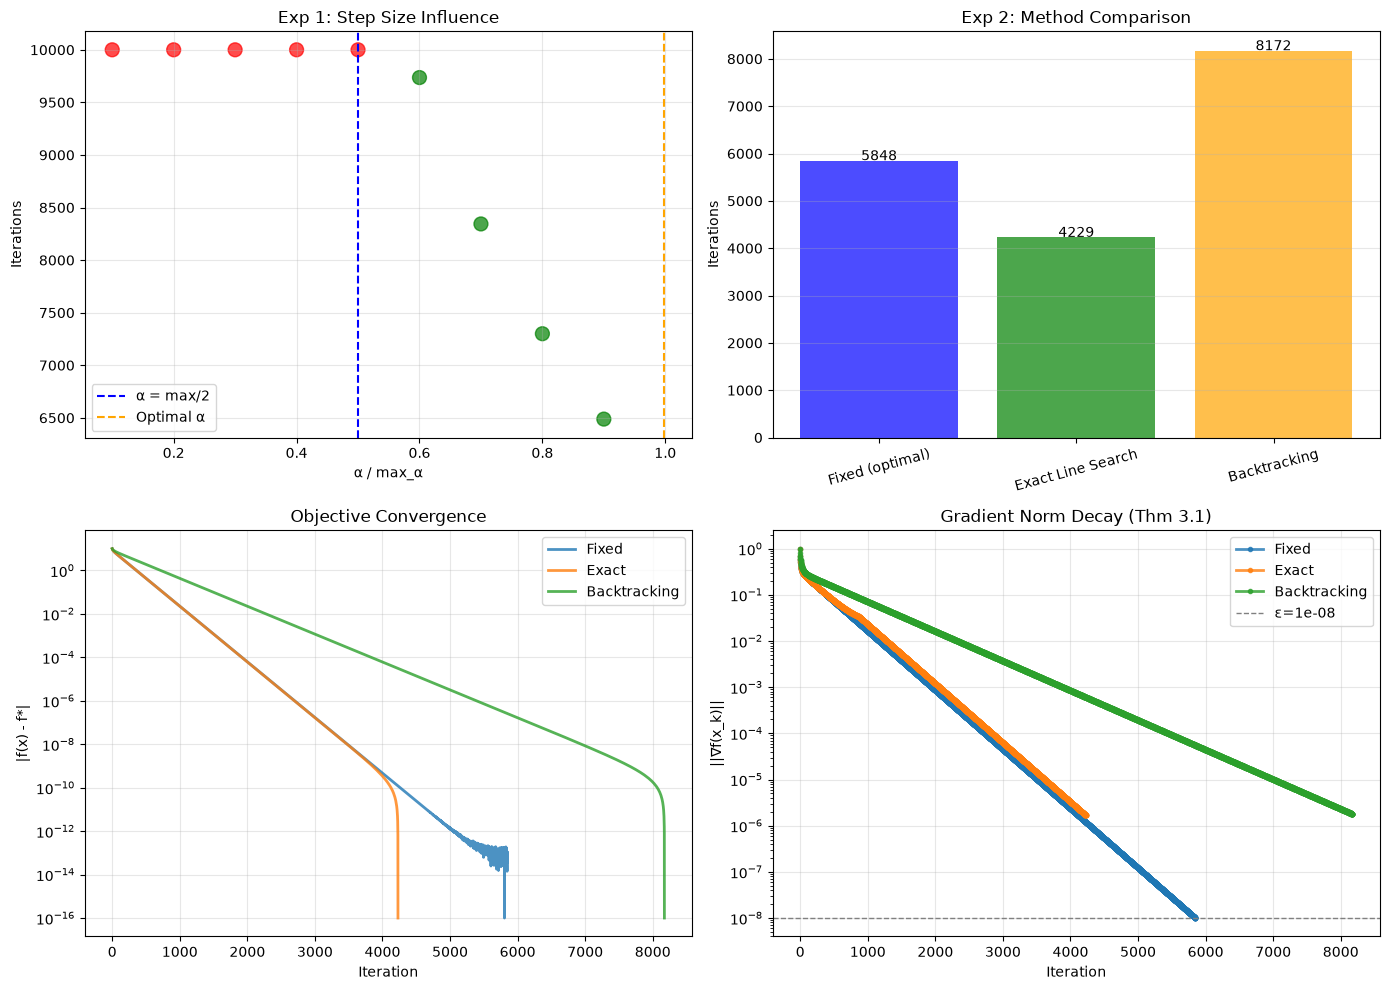


Saved: line_search_exp_n20.png


In [87]:
def run_all_experiments(n=20, max_iter=10000, epsilon=1e-8):
    """Complete experiments with 4 visualization panels (handles empty history)."""
    
    sm = StructuralMechanics(n=n)
    print("=" * 70)
    print(f"Line Search Experiments | n={n}, κ={sm.eta/sm.mu:.2f}")
    print("=" * 70)
    
    # ===== EXP 1: Alpha sweep =====
    print("\nPart 1: Fixed-step gradient descent vs α")
    exp1_data = []
    for ratio in np.linspace(0.1, 0.9, 9):
        alpha = ratio * sm.max_alpha
        try:
            _, k, obj = sm.gradient_descent(np.zeros(n), alpha, epsilon, max_iter)
            exp1_data.append((ratio, k, True, obj))
            print(f"  α={ratio:.1f}*max: {k} iters ✓")
        except:
            exp1_data.append((ratio, max_iter, False, float('inf')))
            print(f"  α={ratio:.1f}*max: diverged ✗")
    
    # ===== EXP 2: Methods with history =====
    print("\nPart 2: Method comparison + convergence curves")
    methods = []
    histories = {}
    
    # Fixed optimal
    alpha_opt = 2/(sm.mu + sm.eta)
    try:
        u_f, k_f, obj_f, hist_f = sm.gradient_descent(np.zeros(n), alpha_opt, 
                                                     epsilon, max_iter, track_history=True)
        methods.append(('Fixed (optimal)', k_f, obj_f)); histories['Fixed'] = hist_f
        print(f"  Fixed (optimal): {k_f} iters, hist_len={len(hist_f['obj']) if hist_f else 0}")
    except:
        methods.append(('Fixed (optimal)', max_iter, float('inf'))); histories['Fixed'] = None
    
    # Exact line search
    try:
        u_e, k_e, obj_e, hist_e = sm.GD_exact_line_search(np.zeros(n), epsilon, 
                                                        max_iter, track_history=True)
        methods.append(('Exact Line Search', k_e, obj_e)); histories['Exact'] = hist_e
        print(f"  Exact Line Search: {k_e} iters, hist_len={len(hist_e['obj']) if hist_e else 0}")
    except:
        methods.append(('Exact Line Search', max_iter, float('inf'))); histories['Exact'] = None
    
    # Backtracking
    try:
        u_b, k_b, obj_b, hist_b = sm.GD_inexact_line_search(np.zeros(n), None, 
                                                          0.5, 1e-4, epsilon, max_iter, 
                                                          track_history=True)
        methods.append(('Backtracking', k_b, obj_b)); histories['Backtracking'] = hist_b
        print(f"  Backtracking: {k_b} iters, hist_len={len(hist_b['obj']) if hist_b else 0}")
    except:
        methods.append(('Backtracking', max_iter, float('inf'))); histories['Backtracking'] = None
    
    # ===== 4-PLOT VISUALIZATION (SAFE FOR EMPTY HISTORY) =====
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Iterations vs alpha
    ax1 = axes[0, 0]
    ratios, iters, convs, objs = zip(*exp1_data)
    colors = ['green' if c else 'red' for c in convs]
    ax1.scatter(ratios, iters, c=colors, s=100, alpha=0.7)
    ax1.axvline(x=0.5, color='blue', linestyle='--', label='α = max/2')
    ax1.axvline(x=alpha_opt/sm.max_alpha, color='orange', linestyle='--', label='Optimal α')
    ax1.set_xlabel('α / max_α'); ax1.set_ylabel('Iterations'); ax1.set_title('Exp 1: Step Size Influence')
    ax1.legend(); ax1.grid(True, alpha=0.3)
    
    # Plot 2: Bar chart comparison
    ax2 = axes[0, 1]
    names = [m[0] for m in methods]; ks = [m[1] for m in methods]
    bars = ax2.bar(names, ks, color=['blue','green','orange'], alpha=0.7)
    ax2.set_ylabel('Iterations'); ax2.set_title('Exp 2: Method Comparison')
    for bar, val in zip(bars, ks): 
        if val < max_iter:  # Only label converged methods
            ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10, str(val), ha='center')
    ax2.tick_params(axis='x', rotation=15); ax2.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Objective convergence (with fallback message)
    ax3 = axes[1, 0]
    any_history = any(h is not None and 'obj' in h for h in histories.values())
    if any_history:
        for name, hist in histories.items():
            if hist is not None and len(hist.get('obj', [])) > 1:
                obj_vals = hist['obj']
                min_obj = min(obj_vals) if min(obj_vals) > float('-inf') else obj_vals[-1] - 0.45
                ax3.semilogy(range(len(obj_vals)), [max(abs(o - min_obj), 1e-16) for o in obj_vals], 
                            label=name, linewidth=2, alpha=0.8)
        ax3.set_xlabel('Iteration'); ax3.set_ylabel('|f(x) - f*|')
        ax3.set_title('Objective Convergence'); ax3.legend(); ax3.grid(True, alpha=0.3)
    else:
        ax3.text(0.5, 0.5, 'Add track_history=True\nto StructuralMechanics class\nfor convergence data', 
                ha='center', va='center', fontsize=12, transform=ax3.transAxes,
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
        ax3.set_xlim(0, 1); ax3.set_ylim(0, 1); ax3.axis('off')
    
    # Plot 4: GRADIENT NORM (with fallback and better visibility)
    ax4 = axes[1, 1]
    any_grad = any(h is not None and 'grad' in h and len(h.get('grad', [])) > 0 
                   for h in histories.values())
    if any_grad:
        for name, hist in histories.items():
            if hist is not None and len(hist.get('grad', [])) > 0:
                grad_vals = hist['grad']
                ax4.semilogy(range(len(grad_vals)), grad_vals, 
                            label=name, linewidth=2, alpha=0.8, marker='o', markersize=3)
        ax4.axhline(y=epsilon, color='gray', linestyle='--', label=f'ε={epsilon}', linewidth=1)
        ax4.set_xlabel('Iteration'); ax4.set_ylabel('||∇f(x_k)||')
        ax4.set_title('Gradient Norm Decay (Thm 3.1)'); ax4.legend(); ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Add track_history=True\nto StructuralMechanics class\nfor gradient data', 
                ha='center', va='center', fontsize=12, transform=ax4.transAxes,
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
        ax4.set_xlim(0, 1); ax4.set_ylim(0, 1); ax4.axis('off')
    
    plt.tight_layout()
    plt.savefig(f'line_search_exp_n{n}.png', dpi=150)
    plt.show()
    print(f"\nSaved: line_search_exp_n{n}.png")

# Run
if __name__ == "__main__":
    run_all_experiments(n=20)